In [2]:
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import defaultdict



def generate_substructure_map(smiles_list: list[str], fp_size: int, radius: int) -> dict:
    """
    Generates a map from ECFP bit position to the SMARTS of substructures
    that activate it.

    Args:
        smiles_list: A list of SMILES strings for your dataset molecules.
        fp_size: The size of the fingerprint (e.g., 128).
        radius: The ECFP radius (e.g., 2 for ECFP4).

    Returns:
        A dictionary where keys are bit positions (int) and values are sets
        of SMARTS strings corresponding to the substructures.
    """
    substructure_map = defaultdict(set)
    print(f"Processing {len(smiles_list)} molecules to build the map...")

    for i, smiles in enumerate(smiles_list):
        if i % 100 == 0 and i > 0:
            print(f"  Processed {i} molecules...")

        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue

        bit_info = {}
        # Use the same parameters as your scikit-fingerprints setup
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=128,
            bitInfo=bit_info,
            useChirality=False, # Match your ECFP settings
            useBondTypes=True,  # Match your ECFP settings
            useFeatures=False, # Set to True for FCFP
        )

        for bit, atom_radius_tuples in bit_info.items():
            for atom_idx, radius_val in atom_radius_tuples:
                # Extract the substructure environment
                if radius_val == 0:
                    # Radius 0 is just the atom itself
                    sub_mol = Chem.MolFromSmarts(f"[{mol.GetAtomWithIdx(atom_idx).GetSmarts()}]")
                else:
                    env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius_val, atom_idx)
                    amap = {}
                    sub_mol = Chem.PathToSubmol(mol, env, atomMap=amap)
                    try:
                        smarts = Chem.MolToSmarts(sub_mol, isomericSmiles=True)
                    except:
                        smarts = sub_mol.GetSmarts()


                # Add the SMARTS to our map for that bit
                substructure_map[bit].add(smarts)

    print("Map generation complete.")
    return dict(substructure_map)

In [3]:
import pandas as pd
# Load your dataset
df1 = pd.read_csv('../../../data/processed_selected_custom_features/data_substrates_june2025_no_outliers.csv')
df2 = pd.read_csv('../../../data/fingerprints_ecfp_128/data_substrates_june2025_no_outliers.csv')
df = df1.merge(df2, on='smiles', how='inner')
df['capacity_max'] = df['capacity_max_x']
df = df.drop(columns=['capacity_max_x', 'capacity_max_y'])
df

,smiles,flatness,radius,diameter,balaban_j_index,%C,%N,%O,MolLogP,num_atoms,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,capacity_max
0,N#Cc1ccc(C#N)cc1,0.051385,4,7,3.075217,80.000000,20.000000,0.000000,1.42996,10,...,0,0,0,0,0,0,0,0,0,628.0
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,1.847534,8,16,1.652035,90.476190,9.523810,0.000000,9.74536,42,...,0,0,0,0,0,0,0,0,0,255.0
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,1.468051,8,16,1.457648,81.818182,13.636364,0.000000,9.33480,44,...,0,0,0,1,0,0,0,0,0,269.0
3,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,0.744660,10,18,1.287446,68.750000,18.750000,0.000000,10.16400,48,...,0,0,0,1,0,0,0,0,0,228.0
4,O=C1c2ccc(Nc3nc(Cl)nc(Cl)n3)cc2C(=O)c2ccc(Nc3n...,0.728578,9,17,1.457455,58.823529,23.529412,5.882353,4.93280,34,...,0,0,0,1,0,1,0,0,0,468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,CCCCCCCCN1C(=O)C2=C(c3ccc(/C=N/c4ccc(-c5cc(-c6...,1.980776,14,28,1.081588,84.848485,7.575758,4.545455,14.06590,66,...,1,1,1,0,0,0,1,0,0,50.0
99,Nc1ccc(-c2ccc3c(c2)C2(c4cc(-c5ccc(N)cc5)ccc4-3...,2.786990,12,23,1.133945,91.935484,6.451613,1.612903,13.00780,62,...,1,1,0,0,0,0,0,0,0,251.0
100,Nc1ccc(-c2ccc(/N=C/c3ccc([Sb](c4ccc(C=O)cc4)c4...,1.681720,11,21,1.397576,82.500000,5.000000,10.000000,4.23880,40,...,1,0,0,1,0,0,0,1,0,768.0
101,Nc1ccc(-c2ccc(/N=C/c3ccc([Sb](c4ccc(C=O)cc4)c4...,1.527354,11,21,1.372479,86.842105,5.263158,5.263158,4.82760,38,...,1,1,0,1,0,0,0,0,0,393.0


In [4]:
df1.columns

Index(['smiles', 'capacity_max', 'flatness', 'radius', 'diameter',
       'balaban_j_index', '%C', '%N', '%O', 'MolLogP', 'num_atoms',
       'num_bonds', 'num_aromatic_rings', 'num_heteroatoms',
       'num_rotatable_bonds', 'num_h_acceptors', 'num_h_donors', 'tpsa',
       'mol_wt'],
      dtype='object')

In [5]:
all_smiles = df['smiles'].tolist()
# Generate the substructure map
substructure_map = generate_substructure_map(
    smiles_list=all_smiles,
    fp_size=128,
    radius=2
)
substructure_map

Processing 103 molecules to build the map...
  Processed 100 molecules...
Map generation complete.


[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerator
[11:05:02] DEPRECATION WARNING: please use MorganGenerat

{22: {'[#6]#[#7]',
  '[#6]-[#6](=[#6])-[#6](-[#6](-[#7])=[#8])=[#6](-[#6])-[#7]',
  '[#6]-[#7](-[#6])-[#6]',
  '[#6]:[#6](-[#6](:[#7]:[#6]):[#7]:[#6]):[#6]',
  '[#6]:[#6](-[#6]-[#6]-[#6]):[#6]',
  '[#6]:[#6](:[#6])-[#6]-[#6]-[#6]',
  '[#6]:[#6]:[#6]:[#6](-[#7+]):[#6]',
  '[#6]:[#6]:[#6]:[#6](-[Sn]):[#16]',
  '[#6]:[#7]:[#6](-[#6](:[#6]):[#6]):[#7]:[#6]',
  '[#7]#[#6]',
  '[#7]-[#6](=[#8])-[#6](=[#6](-[#6])-[#7])-[#6](-[#6])=[#6]'},
 34: {'[#17]-[#6](:[#7]:[#6]):[#7]:[#6]',
  '[#6]#[#7]',
  '[#6]-[#6]#[#7]',
  '[#6]-[#6](:[#6]):[#6]',
  '[#6]-[#6](:[#6]):[#6]:[#6]:[#6]',
  '[#6]-[#6](:[#6]:[#6]:[#6]):[#6]',
  '[#6]-[#7](-[#6]-[#8]-[#6])-[#6]',
  '[#6]-[#7](:[#6]):[#6]',
  '[#6]-[#8]-[#6]-[#7](-[#6])-[#6]',
  '[#6]:[#16]:[#6]',
  '[#6]:[#16]:[#6](-[#6](:[#6]):[#6]):[#7]:[#6]',
  '[#6]:[#6](-[#6]):[#6]:[#6]:[#6]',
  '[#6]:[#6](-[#6]=[#8]):[#16]',
  '[#6]:[#6](-[#8]):[#6](-[#6]=[#7]):[#6]:[#6]',
  '[#6]:[#6]:[#6](-[#6]#[#7]):[#6]:[#6]',
  '[#6]:[#6]:[#6]:[#6](-[#6]):[#6]',
  '[#6]:[#7](-[#

In [6]:
df

,smiles,flatness,radius,diameter,balaban_j_index,%C,%N,%O,MolLogP,num_atoms,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,capacity_max
0,N#Cc1ccc(C#N)cc1,0.051385,4,7,3.075217,80.000000,20.000000,0.000000,1.42996,10,...,0,0,0,0,0,0,0,0,0,628.0
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,1.847534,8,16,1.652035,90.476190,9.523810,0.000000,9.74536,42,...,0,0,0,0,0,0,0,0,0,255.0
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,1.468051,8,16,1.457648,81.818182,13.636364,0.000000,9.33480,44,...,0,0,0,1,0,0,0,0,0,269.0
3,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,0.744660,10,18,1.287446,68.750000,18.750000,0.000000,10.16400,48,...,0,0,0,1,0,0,0,0,0,228.0
4,O=C1c2ccc(Nc3nc(Cl)nc(Cl)n3)cc2C(=O)c2ccc(Nc3n...,0.728578,9,17,1.457455,58.823529,23.529412,5.882353,4.93280,34,...,0,0,0,1,0,1,0,0,0,468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,CCCCCCCCN1C(=O)C2=C(c3ccc(/C=N/c4ccc(-c5cc(-c6...,1.980776,14,28,1.081588,84.848485,7.575758,4.545455,14.06590,66,...,1,1,1,0,0,0,1,0,0,50.0
99,Nc1ccc(-c2ccc3c(c2)C2(c4cc(-c5ccc(N)cc5)ccc4-3...,2.786990,12,23,1.133945,91.935484,6.451613,1.612903,13.00780,62,...,1,1,0,0,0,0,0,0,0,251.0
100,Nc1ccc(-c2ccc(/N=C/c3ccc([Sb](c4ccc(C=O)cc4)c4...,1.681720,11,21,1.397576,82.500000,5.000000,10.000000,4.23880,40,...,1,0,0,1,0,0,0,1,0,768.0
101,Nc1ccc(-c2ccc(/N=C/c3ccc([Sb](c4ccc(C=O)cc4)c4...,1.527354,11,21,1.372479,86.842105,5.263158,5.263158,4.82760,38,...,1,1,0,1,0,0,0,0,0,393.0


50
Shape of our data (X): (103, 144)
Shape of our SHAP values storage array: (103, 144)
--- Processing Fold 1/50 ---


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Processing Fold 2/50 ---
--- Processing Fold 3/50 ---
--- Processing Fold 4/50 ---
--- Processing Fold 5/50 ---
--- Processing Fold 6/50 ---
--- Processing Fold 7/50 ---
--- Processing Fold 8/50 ---
--- Processing Fold 9/50 ---
--- Processing Fold 10/50 ---
--- Processing Fold 11/50 ---
--- Processing Fold 12/50 ---
--- Processing Fold 13/50 ---
--- Processing Fold 14/50 ---
--- Processing Fold 15/50 ---
--- Processing Fold 16/50 ---
--- Processing Fold 17/50 ---
--- Processing Fold 18/50 ---
--- Processing Fold 19/50 ---
--- Processing Fold 20/50 ---
--- Processing Fold 21/50 ---
--- Processing Fold 22/50 ---
--- Processing Fold 23/50 ---
--- Processing Fold 24/50 ---
--- Processing Fold 25/50 ---
--- Processing Fold 26/50 ---
--- Processing Fold 27/50 ---
--- Processing Fold 28/50 ---
--- Processing Fold 29/50 ---
--- Processing Fold 30/50 ---


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


--- Processing Fold 31/50 ---
--- Processing Fold 32/50 ---
--- Processing Fold 33/50 ---
--- Processing Fold 34/50 ---
--- Processing Fold 35/50 ---
--- Processing Fold 36/50 ---
--- Processing Fold 37/50 ---
--- Processing Fold 38/50 ---
--- Processing Fold 39/50 ---
--- Processing Fold 40/50 ---
--- Processing Fold 41/50 ---
--- Processing Fold 42/50 ---
--- Processing Fold 43/50 ---
--- Processing Fold 44/50 ---


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


--- Processing Fold 45/50 ---
--- Processing Fold 46/50 ---
--- Processing Fold 47/50 ---
--- Processing Fold 48/50 ---
--- Processing Fold 49/50 ---
--- Processing Fold 50/50 ---

Loop finished.

Final averaged SHAP values array shape: (103, 144)

Generating global feature importance plot...


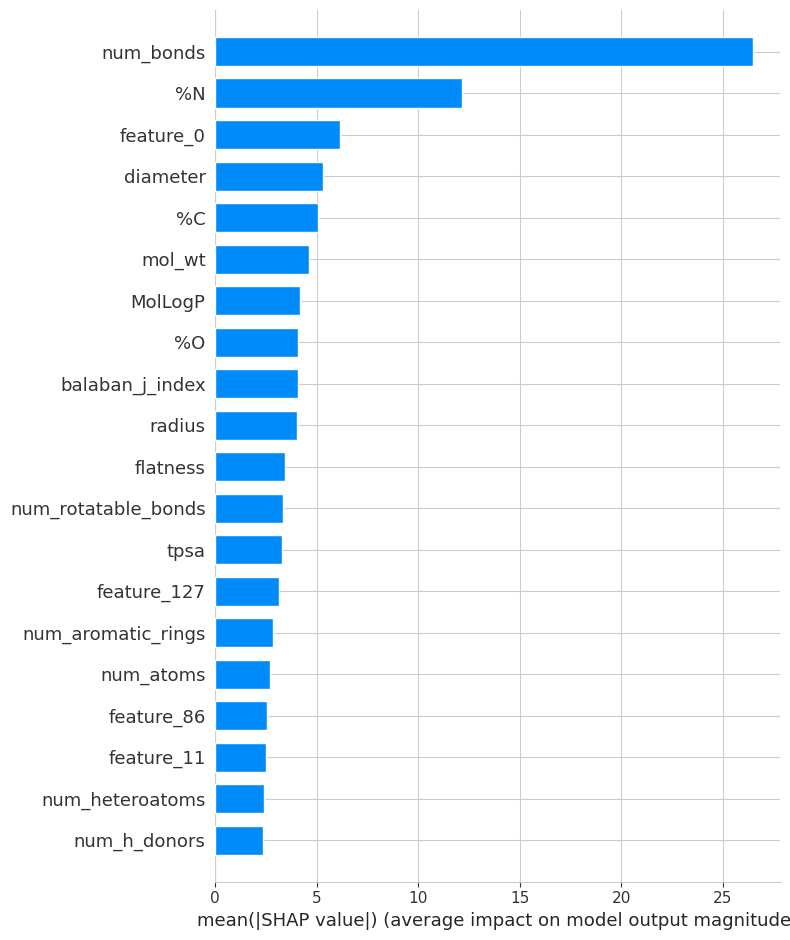

Generating detailed summary plot...


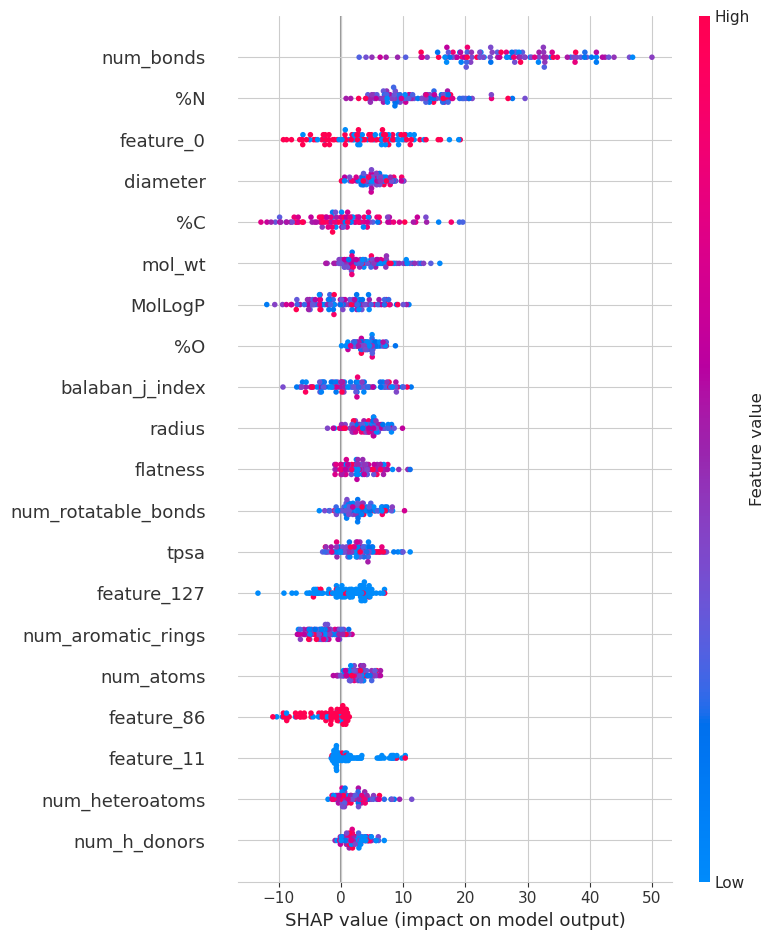

In [7]:
from modules.predictor.data.utils import prepare_data_for_regressors
import copy
from modules.predictor.training_and_evaluation.model_factory import Models
from modules.predictor.training_and_evaluation.train_utils import param_search
import numpy as np
import pandas as pd
from modules.predictor.data.utils import custom_data_kfold
import shap
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.datasets import make_classification

X = df.drop(columns=['smiles', 'capacity_max'])
y = df[['capacity_max']]
folds = custom_data_kfold(X, y, num_splits=10, num_bins=5, random_state=42)
print(len(folds))
# 3. Initialize arrays to store results
# We will store the sum of SHAP values and average them at the end.
# This array will have one row for each sample and one column for each feature.
shap_values_sum = np.zeros(X.shape)
print(f"Shape of our data (X): {X.shape}")
print(f"Shape of our SHAP values storage array: {shap_values_sum.shape}")

for fold, (train_idx, val_idx) in enumerate(folds):
    print(f"--- Processing Fold {fold+1}/{len(folds)} ---")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[val_idx], y.iloc[val_idx]
    X_train, y_train = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
    X_test, y_test = X_test.reset_index(drop=True), y_test.reset_index(drop=True)

    _, model, param_grid = Models().get_model(name='xgboost')
    best_score, best_params = param_search(model, X_train, y_train, 0.7, param_grid, "grid_search")
    model.set_params(**best_params)

    cat_features = []
    num_features = ['flatness', 'radius', 'diameter',
       'balaban_j_index', '%C', '%N', '%O', 'MolLogP', 'num_atoms',
       'num_bonds', 'num_aromatic_rings', 'num_heteroatoms',
       'num_rotatable_bonds', 'num_h_acceptors', 'num_h_donors', 'tpsa',
       'mol_wt']
    X_test_copy = copy.deepcopy(X_test)
    X_test = prepare_data_for_regressors(X_test, (X_train, X_test_copy), numerical_features=num_features, categorical_features=cat_features)
    X_train = prepare_data_for_regressors(X_train, (X_train, X_test_copy), num_features, cat_features)

    model.fit(X_train, y_train)
    explainer = shap.TreeExplainer(model)
    shap_values_fold = explainer.shap_values(X_test)[1]

    shap_values_sum[val_idx] += shap_values_fold

print("\nLoop finished.")

# 5. Average the SHAP values
# Since each sample was in a validation set N_REPEATS times, we divide by that.
shap_values_avg = shap_values_sum / 10

print(f"\nFinal averaged SHAP values array shape: {shap_values_avg.shape}")
# This shape is the same as the original dataset, preserving the number of points.

# 6. Now you can use the aggregated SHAP values for plotting
# The `shap_values_avg` array and the original `X` have the same shape and order.

# Global feature importance (bar plot)
print("\nGenerating global feature importance plot...")
shap.summary_plot(shap_values_avg, X, plot_type="bar", show=True)

# Detailed summary plot (beeswarm plot)
print("Generating detailed summary plot...")
shap.summary_plot(shap_values_avg, X, show=True)

In [12]:
list(substructure_map[0])

['[#6]-[#6](:[#6]):[#6]:[#6]:[#6]',
 '[#6]-[#7](-[#6])-[#6](-[#6](:[#6]):[#6])=[#8]',
 '[#16]:[#6](-[#6](:[#6]:[#6]):[#6]:[#6]):[#7]',
 '[#7]:[#6](:[#6]:[#6](:[#7]):[#6]):[#6]',
 '[#6]:[#6]:[#6](-[#6]):[#6]:[#6]',
 '[#6]-[#6](:[#6]:[#6]):[#6]:[#6]',
 '[#6]:[#6]:[#6](-[#35]):[#6]:[#6]',
 '[#6]=[#8]',
 '[#6]:[#6](-[#6]):[#6]:[#6]:[#6]',
 '[#6]:[#6]:[#6](-[#6](:[#7]):[#16]):[#6]:[#6]',
 '[#6]:[#6](:[#6])-[#6](-[#7](-[#6])-[#6])=[#8]',
 '[#6]:[#6]:[#6]',
 '[#7]:[#6](:[#16]:[#6](-[#6]):[#7]):[#6]',
 '[#6]:[#6]:[#6]:[#6](-[#6]):[#6]',
 '[#6]-[#6](:[#7]):[#16]:[#6](:[#7]):[#6]',
 '[#6]:[#6](=[#8]):[#7]',
 '[#6]-[#6](:[#6]:[#6]:[#6]):[#6]',
 '[#6]-[#6](:[#6]):[#6](:[#6]:[#6])-[#6](=[#8])-[#6]',
 '[#6]-[#6](:[#6]):[#6](:[#6](:[#6])-[#6])-[#8]',
 '[#7]-[#6](:[#6]):[#6]']

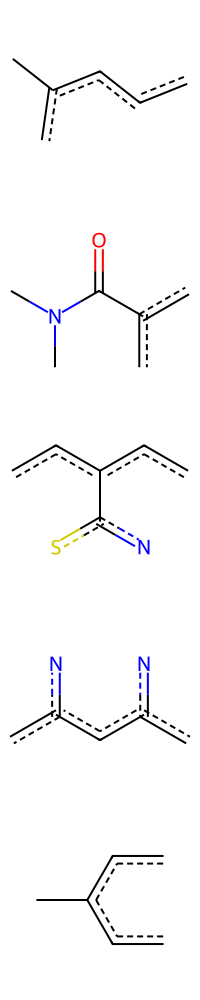

In [24]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont

smarts_list = [
    '[#6]-[#6](:[#6]):[#6]:[#6]:[#6]',
 '[#6]-[#7](-[#6])-[#6](-[#6](:[#6]):[#6])=[#8]',
 '[#16]:[#6](-[#6](:[#6]:[#6]):[#6]:[#6]):[#7]',
 '[#7]:[#6](:[#6]:[#6](:[#7]):[#6]):[#6]',
    '[#6]-[#6](:[#6]:[#6]):[#6]:[#6]',
]
query_mols = []
valid_smarts = []
for s in smarts_list:
    mol = Chem.MolFromSmarts(s)
    if mol:
        query_mols.append(mol)
        valid_smarts.append(s)
    else:
        print(f"Warning: Could not parse SMARTS string: {s}")

# Generate the grid image
# legends: text to display below each molecule
# molsPerRow: how many molecules to display in each row
img = Draw.MolsToGridImage(query_mols, molsPerRow=1)
img

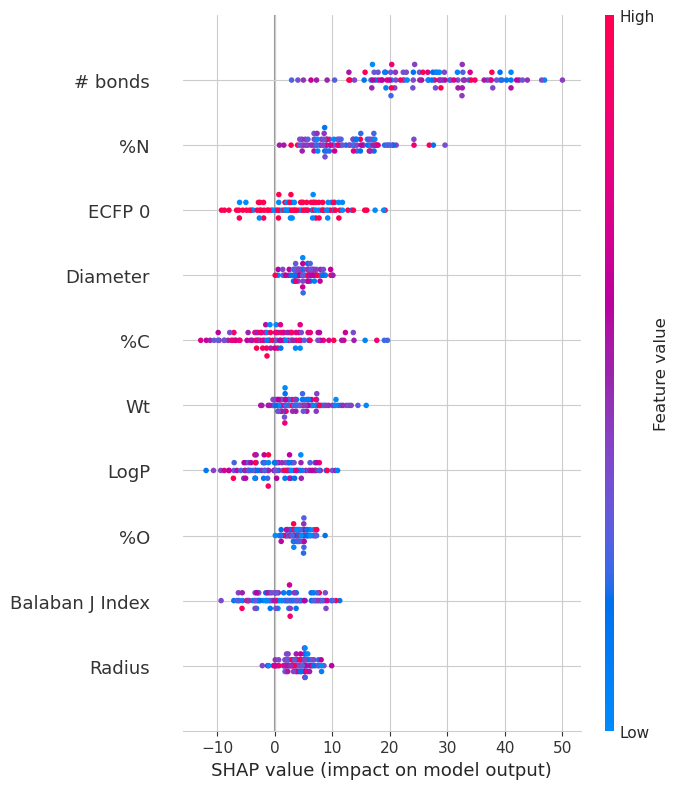

In [11]:
f_names = {
   "num_bonds": "# bonds",
    "feature_0": "ECFP 0",
    "diameter":"Diameter",
    "mol_wt":"Wt",
    "MolLogP":"LogP",
    "balaban_j_index":"Balaban J Index",
    "radius":"Radius",
}
X = X.rename(columns=f_names)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,4))
shap.summary_plot(shap_values_avg, X, max_display=10, plot_size=(7,8), show=True)